## Final test on holdout dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

Load data

In [2]:

def load_NPI_measurements(filepath="../NPI250to421.csv"):

    features = [
        "npi",
        "pupil_size",
        "pupil_min",
        "ch",
        "const_velocity",
        "max_const_velocity",
        "latency",
        "dilat_velocity",
    ]

    # Only load needed columns
    cols = ["record_id", "redcap_repeat_instance"]

    for feat in features:
        cols.extend([
            f"{feat}_right",
            f"{feat}_left",
            f"{feat}_right_2",
            f"{feat}_left_2",
        ])

    df = pd.read_csv(filepath, usecols=lambda c: c in cols)

    # Baseline rows have NaN repeat_instance
    df["redcap_repeat_instance"] = (
        df["redcap_repeat_instance"]
        .fillna(0)
        .astype(int)
    )

    # Follow-up rows store values in *_2 columns
    followup_mask = df["redcap_repeat_instance"] > 0

    for feat in features:
        for side in ["right", "left"]:

            normal_col = f"{feat}_{side}"
            followup_col = f"{feat}_{side}_2"

            df.loc[followup_mask, normal_col] = (
                df.loc[followup_mask, followup_col]
            )

    # Remove *_2 columns
    df = df.drop(
        columns=[c for c in df.columns if c.endswith("_2")]
    )

    # Remove rows where NPI is missing
    df = df.dropna(
        subset=["npi_right", "npi_left"],
        how="all"
    )

    # Rename repeat instance
    df = df.rename(
        columns={"redcap_repeat_instance": "instance"}
    )

# Make seperate dataframes

    right_cols = ["record_id", "instance"] + [c for c in df.columns if c.endswith("_right")]
    df_right = df[right_cols].copy()
    df_right.columns = [c.replace("_right", "") for c in df_right.columns]


    left_cols = ["record_id", "instance"] + [c for c in df.columns if c.endswith("_left")]
    df_left = df[left_cols].copy()
    df_left.columns = [c.replace("_left", "") for c in df_left.columns]

    return (df_right.reset_index(drop=True), df_left.reset_index(drop=True))

df_right, df_left = load_NPI_measurements()


Load healthy to create z-scores and remove rows with important missing values

In [3]:
df_l = pd.read_csv("../Pupilometri/HC_left_NPi.csv")
df_r = pd.read_csv("../Pupilometri/HC_right_NPi.csv")

df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)

def z_score(x, mean, std):
    return (x - mean) / std


# Keep only record_id >= 253
df_right = df_right[df_right["record_id"] >= 253].copy()
df_left = df_left[df_left["record_id"] >= 253].copy()

# Drop rows with missing values in required variables
required_cols = [
    "npi",
    "pupil_size",
    "pupil_min",
    "ch"
]

df_right = df_right.dropna(subset=required_cols)
df_left = df_left.dropna(subset=required_cols)

df_right = df_right.reset_index(drop=True)
df_left = df_left.reset_index(drop=True)



# Right eye
df_right["z_pupil_size"] = z_score(df_right["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df_right["z_pupil_min"] = z_score(df_right["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df_right["z_ch"] = z_score(df_right["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df_right["z_const_velocity"] = z_score(df_right["const_velocity"], df_HC["const_velocity"].dropna().mean(), df_HC["const_velocity"].dropna().std())
df_right["z_max_const_velocity"] = z_score(df_right["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df_right["z_dilat_velocity"] = z_score(df_right["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df_right["z_latency"] = z_score(df_right["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())


# Left eye
df_left["z_pupil_size"] = z_score(df_left["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df_left["z_pupil_min"] = z_score(df_left["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df_left["z_ch"] = z_score(df_left["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df_left["z_const_velocity"] = z_score(df_left["const_velocity"], df_HC["const_velocity"].dropna().mean(), df_HC["const_velocity"].dropna().std())
df_left["z_max_const_velocity"] = z_score(df_left["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df_left["z_dilat_velocity"] = z_score(df_left["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df_left["z_latency"] = z_score(df_left["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())


df_left["eye"] = "left"
df_right["eye"] = "right"

df = pd.concat([df_left, df_right], ignore_index=True)

In [4]:
print("size",df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
print("min",df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
print("ch",df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())

size 4.85 1.0441166562394906
min 3.0976000000000004 0.7601357558666338
ch 36.16 6.038515833330882


### Test


=== PERFORMANCE ===
RMSE: 0.1092
MAE:  0.0770
R2:   0.9665


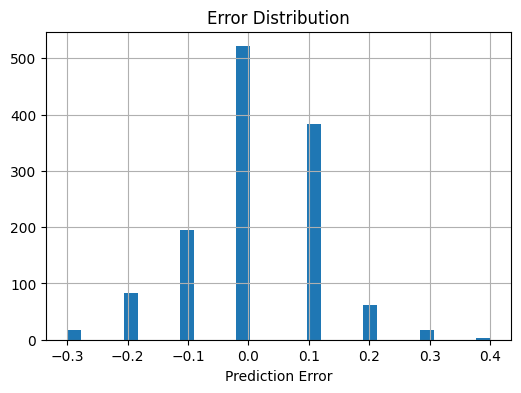

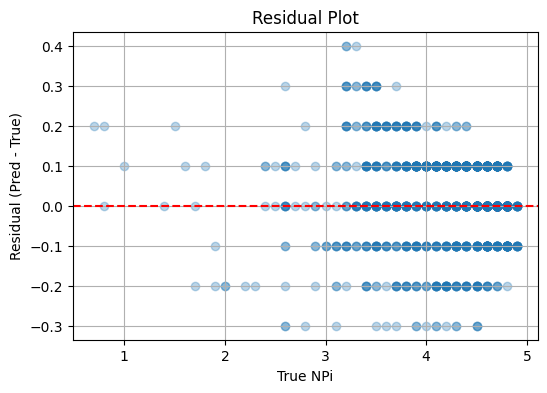

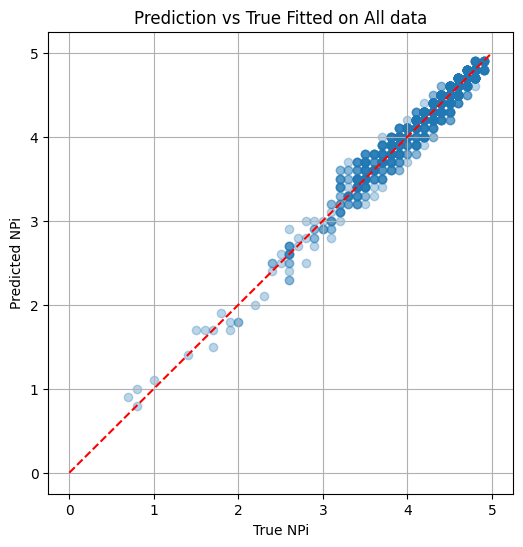

In [ ]:
# Define x and y and what to group on
TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
    "z_ch"
]

X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values

# Define the models

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Pupil min model
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

#  pupil size model
def sigmoid_plus_threshold_linear(x, A, k, x0, m, b, x_thresh):
    return A * sigmoid(k * (x - x0)) + m * np.maximum(0, x - x_thresh) + b

#  CH model
def sigmoid_shifted(x, A, k, x0, b):
    return A * sigmoid(k * (x - x0)) + b


# Parameters for each feature (From NPI_CV_minmaxch.ipynb (recontruction))

params_size = np.array([10.,  2.09039779, -3.44802467,  1.04197699, -9.89640531, -0.56237204])
params_min = np.array([ 5.94813019,  0.25853888, -6.38849346])
params_ch = np.array([ 1.30916994,  1.07043078, -4.51350752, -0.97346123])
intercept = 1.6648589335529862
a = 0.922349
b = -0.558401

# Prediction model
def predict_z_full(X):
    return (
        intercept
        + sigmoid_plus_threshold_linear(X.iloc[:,0].values, *params_size)
        + exp_decay(X.iloc[:,1].values, *params_min)
        + sigmoid_shifted(X.iloc[:,2].values, *params_ch)
    )

z_pred = predict_z_full(X)
z_final = a * z_pred + b
y_pred = np.round(sigmoid(z_final) * 5,1)
rmse = np.sqrt(mean_squared_error(y_raw, y_pred))
mae  = mean_absolute_error(y_raw, y_pred)
r2   = r2_score(y_raw, y_pred)

print("\n=== PERFORMANCE ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

residuals = y_pred-y_raw
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_raw, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("True NPi")
plt.ylabel("Residual (Pred - True)")
plt.title("Residual Plot")
plt.grid()
plt.show()


plt.figure(figsize=(6,6))
plt.scatter(y_raw, y_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True Fitted on All data")
plt.grid()
plt.show()